In [1]:
import pandas as pd

In [2]:
train_df = pd.read_csv('../results/outputs/Selected/train_top10_features.csv')
test_df = pd.read_csv('../results/outputs/Selected/test_top10_features.csv')

train_df_pca = pd.read_csv('../results/outputs/PCA/pca_train.csv')
test_df_pca = pd.read_csv('../results/outputs/PCA/pca_test.csv')

In [3]:
feature_cols = [c for c in train_df.columns if c != "target"]

x_train = train_df[feature_cols]
y_train = train_df["target"]

x_test = test_df[feature_cols]
y_test = test_df["target"]

In [4]:
feature_cols = [c for c in train_df_pca.columns if c != "target"]

x_train_pca = train_df_pca[feature_cols]
y_train_pca = train_df_pca["target"]

x_test_pca = test_df_pca[feature_cols]
y_test_pca = test_df_pca["target"]

In [5]:
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.metrics import classification_report, accuracy_score

In [6]:
#First train with the ANOVA-10 features
#Default QDA cannot fit these features: blood_pressure is constant inside the High class so its covariance matrix is singular
#So a small reg_param (0.01) is used for the baseline

In [7]:
qda = QuadraticDiscriminantAnalysis(reg_param=0.01)
qda.fit(x_train, y_train)

qda_preds = qda.predict(x_test)
qda_accuracy = accuracy_score(y_test, qda_preds)

print("QDA Accuracy:", qda_accuracy)
print(classification_report(y_test, qda_preds))

QDA Accuracy: 0.8909090909090909
              precision    recall  f1-score   support

           0       0.97      0.81      0.88        74
           1       0.96      0.92      0.94        72
           2       0.79      0.95      0.86        74

    accuracy                           0.89       220
   macro avg       0.90      0.89      0.89       220
weighted avg       0.90      0.89      0.89       220



In [8]:
#Try with PCA features

In [9]:
qda_pca = QuadraticDiscriminantAnalysis()
qda_pca.fit(x_train_pca, y_train_pca)

qda_preds_pca = qda_pca.predict(x_test_pca)
qda_accuracy_pca = accuracy_score(y_test_pca, qda_preds_pca)

print("QDA Accuracy (PCA):", qda_accuracy_pca)
print(classification_report(y_test_pca, qda_preds_pca))

QDA Accuracy (PCA): 0.8909090909090909
              precision    recall  f1-score   support

           0       0.97      0.84      0.90        74
           1       0.93      0.92      0.92        72
           2       0.80      0.92      0.86        74

    accuracy                           0.89       220
   macro avg       0.90      0.89      0.89       220
weighted avg       0.90      0.89      0.89       220



In [10]:
#Both feature sets give the same test accuracy so deciding with the CV score after tuning
#QDA only has reg_param to tune

In [11]:
from sklearn.model_selection import GridSearchCV

In [12]:
param_grid = {
    "reg_param": [0.01, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9],
}

grid_qda = GridSearchCV(
    QuadraticDiscriminantAnalysis(),
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1
)

grid_qda.fit(x_train, y_train)

Fitting 5 folds for each of 13 candidates, totalling 65 fits


,estimator,QuadraticDisc...nantAnalysis()
,param_grid,"{'reg_param': [0.01, 0.05, ...]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,priors,None


In [13]:
grid_qda_pca = GridSearchCV(
    QuadraticDiscriminantAnalysis(),
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1
)

grid_qda_pca.fit(x_train_pca, y_train_pca)

Fitting 5 folds for each of 13 candidates, totalling 65 fits


,estimator,QuadraticDisc...nantAnalysis()
,param_grid,"{'reg_param': [0.01, 0.05, ...]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,priors,None


In [14]:
print("Best QDA parameters (ANOVA-10):", grid_qda.best_params_)
print("Best QDA CV accuracy (ANOVA-10):", grid_qda.best_score_)

print("Best QDA parameters (PCA):", grid_qda_pca.best_params_)
print("Best QDA CV accuracy (PCA):", grid_qda_pca.best_score_)

Best QDA parameters (ANOVA-10): {'reg_param': 0.2}
Best QDA CV accuracy (ANOVA-10): 0.8852272727272726
Best QDA parameters (PCA): {'reg_param': 0.9}
Best QDA CV accuracy (PCA): 0.884090909090909


In [15]:
#ANOVA-10 features have the higher CV accuracy so using them for the final model

In [16]:
best_qda = grid_qda.best_estimator_

tuned_qda_preds = best_qda.predict(x_test)
tuned_qda_accuracy = accuracy_score(y_test, tuned_qda_preds)

print("Tuned QDA Test Accuracy:", tuned_qda_accuracy)
print(classification_report(y_test, tuned_qda_preds))

Tuned QDA Test Accuracy: 0.9045454545454545
              precision    recall  f1-score   support

           0       0.93      0.86      0.90        74
           1       0.97      0.92      0.94        72
           2       0.83      0.93      0.88        74

    accuracy                           0.90       220
   macro avg       0.91      0.90      0.91       220
weighted avg       0.91      0.90      0.91       220



In [17]:
tuned_qda_preds_train = best_qda.predict(x_train)
print("Tuned QDA Train Accuracy:", accuracy_score(y_train, tuned_qda_preds_train))

Tuned QDA Train Accuracy: 0.9090909090909091


In [18]:
import joblib
joblib.dump(best_qda, "../results/model_trained_files/qda_model.pkl")

['../results/model_trained_files/qda_model.pkl']

In [19]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

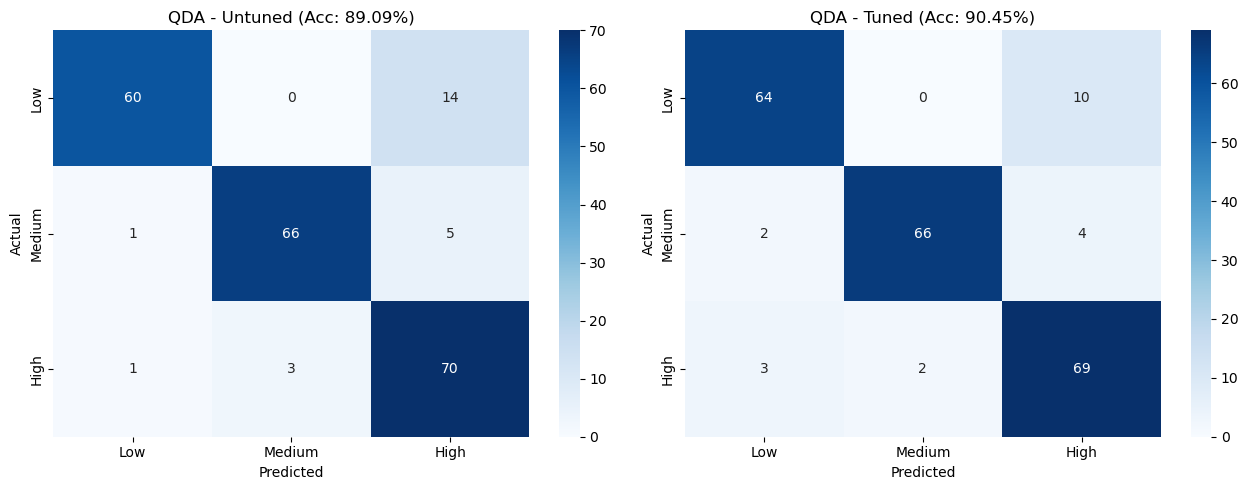

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cm_unt = confusion_matrix(y_test, qda_preds)
sns.heatmap(cm_unt, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Low', 'Medium', 'High'], yticklabels=['Low', 'Medium', 'High'])
axes[0].set_title(f"QDA - Untuned (Acc: {qda_accuracy:.2%})")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

cm_tn = confusion_matrix(y_test, tuned_qda_preds)
sns.heatmap(cm_tn, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Low', 'Medium', 'High'], yticklabels=['Low', 'Medium', 'High'])
axes[1].set_title(f"QDA - Tuned (Acc: {tuned_qda_accuracy:.2%})")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.savefig("../results/eda_visualizations/qda_confusion_comparison_tuned_vs_untuned.png", dpi=150, bbox_inches='tight')
plt.show()